In [1]:
%matplotlib widget
import ipywidgets as widgets
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from mterrain.functions import univariate_slope

**Univariate Slopes**

Slope like behavior is achieved using a rational function whose graph is sigmoidal:

$$f\left(x\right)=\frac{h}{2}\left(1+\frac{arg\left(x\right)}{\sqrt{1+arg\left(x\right)^2}}\right)$$

where

$$arg\left(x\right)=\frac{2s}{h}\left(x-c\right)$$

Function paramters relate to curve shape as follows:

 - $h$ : the approximate change in height (behavior is asymptotic, not exact)
 - $c$ : the center of the slope
 - $s$ : the slope of the curve at its center

interactive(children=(FloatSlider(value=25.0, description='Height', max=250.0, min=-250.0, step=2.1), FloatSli…

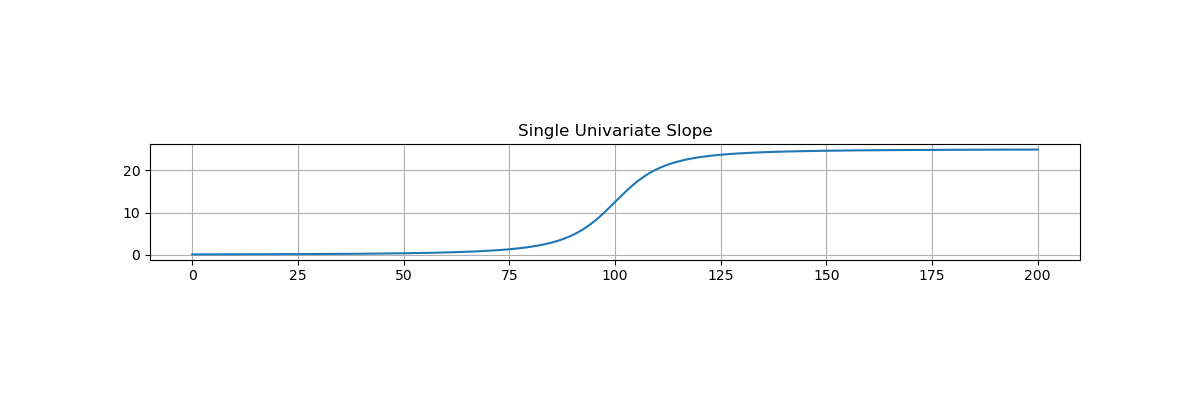

In [2]:
x = np.linspace(0, 200, 400)
f = univariate_slope(25, 100, 1)

fig, ax = plt.subplots(figsize=(12, 4))
ax.set_title("Single Univariate Slope")
line, = ax.plot(x, f(x))
ax.set_aspect('equal')
ax.grid(True)

def update(Height=25.0, Center=100.0, Slope=1.0):
    f = univariate_slope(Height, Center, Slope)
    line.set_ydata(f(x))
    ax.relim()
    ax.autoscale_view()
    fig.canvas.draw_idle()

widgets.interact(update, Height = (-250.0, 250.0, 2.1), Center = (25.0, 175.0, 5.0), Slope = (-8.0, 8.0, 0.21));

Output()

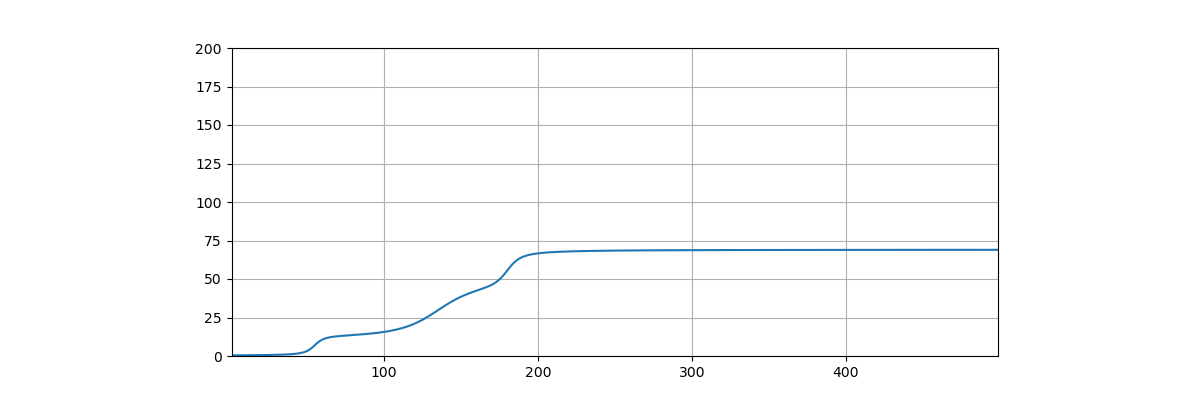

In [3]:
xs = np.linspace(0, 500, 400)
fs = univariate_slope([12.0, 35.0, 22.0], [55.0, 135.0, 180.0], [0.9, 0.65, 1.2])

fig, ax = plt.subplots(figsize=(12, 4))
line, = ax.plot(xs, fs(x))
ax.set_aspect('equal')
ax.set_xlim(1,499)
ax.set_ylim(0, 200)
ax.grid(True)

h1 = widgets.FloatSlider(description="Height 1", min=2.0, max=60.0, value=12.0)
c1 = widgets.FloatSlider(description="Center 1", min=20.0, max=350.0,value=55.0)
s1 = widgets.FloatSlider(description="Slope 1", min=0.1, max=3.5, value=0.9)

h2 = widgets.FloatSlider(description="Height 2", min=2.0, max=60.0, value=35.0)
c2 = widgets.FloatSlider(description="Center 2", min=20.0, max=350.0, value=135.0)
s2 = widgets.FloatSlider(description="Slope 2", min=0.1, max=3.5, value=0.65)

h3 = widgets.FloatSlider(description="Height 3", min=2.0, max=60.0, value=22.0)
c3 = widgets.FloatSlider(description="Center 3", min=20.0, max=350.0, value=180.0)
s3 = widgets.FloatSlider(description="Slope 3", min=0.1, max=3.5, value=1.2)

ui = widgets.HBox([widgets.VBox([h1, c1, s1]), widgets.VBox([h2, c2, s2]), widgets.VBox([h3, c3, s3])])

def update_sum_plot(h1=12.0, c1=55.0, s1=0.9, h2=35.0, c2=135.0, s2=0.65, h3=22.0, c3=180.0, s3=1.2):
    fs = univariate_slope([h1,h2,h3], [c1,c2,c3], [s1,s2,s3])
    line.set_ydata(fs(xs))
    ax.relim()
    ax.autoscale_view()
    fig.canvas.draw_idle()

out = widgets.interactive_output(update_sum_plot, {'c1': c1, 'h1': h1, 's1': s1, 'c2': c2, 'h2': h2, 's2': s2, 'c3': c3, 'h3': h3, 's3': s3})
display(ui, out)